# Phase 3' — Usage Trends

Replaces NOTEBOOK_OUTLINE.md's old Phase 3 ("role classification" —
Pocket Passer / 3-Down Back / Slot WR, etc.), dropped because a role label
is a category that forces a player into one bucket of a fixed set using
thresholds picked by eye, and says nothing about whether that role is
CHANGING right now — which is the thing a manager actually needs each
week. This builds `add_trend_features` and `get_usage_trend_leaders`
(`src/usage.py` Family 7) instead: a continuous, normalized trend signal
per player, plus riser/faller lists.

Before writing any production code, this notebook settles the one open
design question with data rather than assumption: does a usage rise
measured over a 3-week half-life actually predict the following week's
usage staying elevated, compared to 4 and 5? Sections 1-2 are that study;
section 3 exercises the resulting `src/usage.py` functions end to end on
real data.

## What was settled during this build

**Window: 3 weeks, unchanged.** Tested whether a usage rise measured over
a 3-, 4-, or 5-week EWM half-life predicts the FOLLOWING game's usage
staying above season baseline ("holds") vs. falling back to it ("reverts").
3 won on every one of target_share/carry_share/offense_pct/
rz_opportunity_share, on both hold-rate and correlation with next-game
usage, monotonically (3 > 4 > 5 in every case, over 21k+ real player-weeks
per feature — see section 1). So the trend signal reuses
`add_rolling_features`'s EXISTING `<feat>_ewm3`/`<feat>_s2d` columns for
target_share/carry_share/offense_pct directly — no second, competing
half-life constant.

**rz_opportunity_share is new.** Family 4 has `rz_target_share` and
`rz_carry_share` separately, with different denominators (team RZ targets
vs. team RZ carries), so they can't be summed directly into one honest
combined share. Built here as `(rz_targets + rz_carries) / (team_rz_targets
+ team_rz_carries)`, rolled with the same halflife=3 mechanics as
`add_rolling_features` — but deliberately kept OUT of
`ROLLING_SOURCE_COLUMNS`. Adding it there would silently make it a new
`src/model.py` training feature (`FEATURE_COLUMNS` is derived FROM
`ROLLING_OUTPUT_COLUMNS`), retroactively changing the already-published,
already-validated Phase 6 model. This family is a display/export-layer
derived feature, downstream of the model, not a new model input.

**Signal = (ewm3 − s2d) / vol, not the raw gap.** A raw percentage-point
gap isn't comparable across players — a bell-cow RB's target_share
naturally swings more in absolute terms than a committee back's. Dividing
by the player's own season-to-date volatility (the already-existing
`<feat>_vol` column) turned out to matter empirically, not just
conceptually: at a fixed z-threshold, hold-rate clearly beats a raw
top-quartile-gap threshold at a comparable sample size (section 2).

**Direction threshold: z > 0.25.** Checked 0.0/0.25/0.5/0.75/1.0 against
real hold-rates (section 2). 0.25 keeps a workable ~13-20% of eligible
weeks flagged per direction while clearly beating a 0.0 (any positive gap)
cutoff; higher thresholds cut the flagged sample to under 2% of weeks for
a marginal further gain — too thin a list to be useful.

**Minimum games played: 5.** Below this, the season-to-date mean/vol the
signal divides by are themselves too thin to trust — raising the floor
from 2 to 8 games monotonically improved correlation with next-game usage
(target_share: 0.085 at >=2 games vs. 0.123 at >=8), but 8 would exclude
nearly half of every season from ever appearing on a riser/faller list. 5
is the floor the window/threshold study itself was run under, not a
separate, unjustified number picked after the fact.

**Honesty note on rz_opportunity_share.** Even at the validated window and
threshold, its hold-rate stays under 50% — a "rise" reverts more often
than it holds. Red-zone opportunities are a low-volume, high-variance
event category, and this signal is real but clearly noisier than the other
three. Shipped anyway (it was explicitly asked for), with that caveat
carried into `src/export.py`'s `CAVEATS`.

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
from src.usage import (
    FANTASY_POSITIONS, TREND_SOURCE_FEATURES, TREND_DIRECTION_THRESHOLD, MIN_GAMES_FOR_TREND,
    EWM_HALFLIFE, add_trend_features, get_usage_trend_leaders,
)

POSITION_COLORS = {'QB': '#0891b2', 'RB': '#f97316', 'WR': '#22c55e', 'TE': '#a855f7'}

## 1. Load data

Reads `weekly_features.parquet` (from `03_usage_features.ipynb`) rather
than rebuilding Families 1-6 — this notebook is about the trend layer,
not re-deriving what's already validated.

In [3]:
df = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'weekly_features.parquet')
print(f"{len(df):,} rows, seasons {df['season'].min()}-{df['season'].max()}, positions {sorted(df['position'].unique())}")

45,693 rows, seasons 2018-2025, positions ['QB', 'RB', 'TE', 'WR']


## 2. Window-choice study

For target_share, carry_share, offense_pct, and a raw `rz_opportunity_share`
(built here, ahead of `add_trend_features`, purely for this comparison):
compute a "recent" value via `.ewm(halflife=W, min_periods=1).mean()`,
shifted 1 within `(player_id, season)` — the exact mechanics
`add_rolling_features` already uses — for W in {3, 4, 5}. Compare against
the ALREADY-EXISTING `<feat>_s2d` baseline (window-independent, so it's the
same baseline for every W) and the actual NEXT row's value (row-based, not
calendar-based, matching this project's existing EWM convention — see
`add_rolling_features`'s docstring).

Two metrics per (feature, W), both computed only on player-weeks with at
least 5 prior in-season games (so 3 vs. 4 vs. 5 are compared on the exact
same rows — W=5 shouldn't look artificially different just because its
own eligibility would otherwise start later):

- **hold_rate**: among weeks flagged as a "rise" (recent_W − s2d > 0),
  what fraction of the FOLLOWING week's actual value is still above that
  week's s2d baseline (holds) vs. at/below it (reverts, i.e. the "rise"
  was noise)?
- **corr**: Pearson correlation between (recent_W − s2d) at week t and
  (actual_next − s2d) at week t — how much of next week's deviation
  from baseline the trend signal explains, continuously.

In [4]:
study_df = df[df['position'].isin(FANTASY_POSITIONS)].copy()
study_df['rz_opportunities'] = study_df['rz_targets'] + study_df['rz_carries']
study_df['team_rz_opportunities'] = study_df['team_rz_targets'] + study_df['team_rz_carries']
study_df['rz_opportunity_share'] = study_df['rz_opportunities'] / study_df['team_rz_opportunities']

sorted_df = study_df.sort_values(['player_id', 'season', 'week']).reset_index(drop=True)
group_keys = [sorted_df['player_id'], sorted_df['season']]
grouped = sorted_df.groupby(['player_id', 'season'], sort=False)

def _shift(s):
    return s.groupby(group_keys, sort=False).shift(1)

# s2d/vol for rz_opportunity_share don't exist on the input frame yet (new
# metric, not part of Family 6) -- built here with the SAME expanding-mean
# mechanics as every other _s2d column, for this study only.
sorted_df['rz_opportunity_share_s2d'] = _shift(grouped['rz_opportunity_share'].expanding().mean().droplevel([0, 1]))
sorted_df['games_played'] = grouped.cumcount()

WINDOW_FEATURES = ['target_share', 'carry_share', 'offense_pct', 'rz_opportunity_share']
WINDOWS = [3, 4, 5]
MIN_GAMES_FOR_STUDY = 5

results = []
for feat in WINDOW_FEATURES:
    s2d_col = f'{feat}_s2d'
    actual_next = grouped[feat].shift(-1)
    for W in WINDOWS:
        ewm_raw = grouped[feat].ewm(halflife=W, min_periods=1).mean().droplevel([0, 1])
        recent = _shift(ewm_raw)

        elig = (sorted_df['games_played'] >= MIN_GAMES_FOR_STUDY) & actual_next.notna()
        gap = recent - sorted_df[s2d_col]
        next_dev = actual_next - sorted_df[s2d_col]
        m = elig & gap.notna() & next_dev.notna()

        rise = m & (gap > 0)
        n_rise = int(rise.sum())
        hold_rate = (next_dev[rise] > 0).sum() / n_rise if n_rise else float('nan')
        corr = gap[m].corr(next_dev[m])

        results.append({'feature': feat, 'window': W, 'n': int(m.sum()), 'n_rise': n_rise,
                         'hold_rate': round(hold_rate, 4), 'corr': round(corr, 4)})

window_results = pd.DataFrame(results)
window_results

,feature,window,n,n_rise,hold_rate,corr
0,target_share,3,21626,10238,0.4982,0.1021
1,target_share,4,21626,10324,0.4972,0.1004
2,target_share,5,21626,10386,0.4960,0.0992
3,carry_share,3,21626,6345,0.4123,0.2119
4,carry_share,4,21626,6452,0.4100,0.2070
5,carry_share,5,21626,6492,0.4079,0.2037
6,offense_pct,3,21614,11674,0.6186,0.2786
7,offense_pct,4,21614,11660,0.6160,0.2731
8,offense_pct,5,21614,11666,0.6150,0.2695
9,rz_opportunity_share,3,21108,9377,0.3891,0.0493


In [5]:
print('--- Winner per feature (by corr) ---')
for feat in WINDOW_FEATURES:
    sub = window_results[window_results['feature'] == feat]
    best = sub.loc[sub['corr'].idxmax()]
    print(f"{feat}: W={int(best['window'])}  (corr={best['corr']}, hold_rate={best['hold_rate']})")

print()
print('--- Mean across features, per window ---')
print(window_results.groupby('window')[['hold_rate', 'corr']].mean().round(4))

--- Winner per feature (by corr) ---
target_share: W=3  (corr=0.1021, hold_rate=0.4982)
carry_share: W=3  (corr=0.2119, hold_rate=0.4123)
offense_pct: W=3  (corr=0.2786, hold_rate=0.6186)
rz_opportunity_share: W=3  (corr=0.0493, hold_rate=0.3891)

--- Mean across features, per window ---
        hold_rate    corr
window                   
3          0.4796  0.1605
4          0.4777  0.1573
5          0.4766  0.1551


**3 wins on every feature, on both metrics, monotonically.** No
feature prefers 4 or 5 over 3 — not a close call decided by picking the
best per-feature winner, the ranking is 3 > 4 > 5 in every single row of
the table above. `EWM_HALFLIFE` (already 3, used throughout Family 6)
stays as-is; the trend signal below reuses the existing `_ewm3`/`_s2d`
columns for target_share/carry_share/offense_pct without recomputing them.

Also worth noting plainly: hold_rate at the loose "any positive gap"
threshold is *below* 50% for carry_share and rz_opportunity_share even at
the winning window — a raw sign-only "rise" reverts more often than it
holds for those two. That's what motivates normalizing by volatility and
picking a real magnitude threshold in section 3, rather than shipping a
"rising/falling" label off the sign of the gap alone.

## 3. Direction-threshold study

Same setup, W=3 only (the validated winner), but instead of "any positive
gap," flag a rise using `z = gap / vol` (the already-existing `<feat>_vol`
expanding-std column) at increasing thresholds, and check whether hold-rate
improves — i.e., whether normalizing by the player's own volatility
produces a MORE reliable "rise" than a raw gap does.

In [6]:
EWM_HALFLIFE  # confirm this notebook is using the same constant src/usage.py does

3

In [7]:
threshold_rows = []
for feat in WINDOW_FEATURES:
    s2d_col, vol_col = f'{feat}_s2d', f'{feat}_vol'
    if vol_col not in sorted_df.columns:
        # rz_opportunity_share_vol doesn't exist on the input frame -- build
        # it here the same way s2d was built above, for this study only.
        sorted_df[vol_col] = _shift(grouped[feat].expanding().std().droplevel([0, 1]))

    actual_next = grouped[feat].shift(-1)
    ewm_raw = grouped[feat].ewm(halflife=EWM_HALFLIFE, min_periods=1).mean().droplevel([0, 1])
    recent = _shift(ewm_raw)

    elig = (sorted_df['games_played'] >= MIN_GAMES_FOR_STUDY) & actual_next.notna()
    gap = recent - sorted_df[s2d_col]
    next_dev = actual_next - sorted_df[s2d_col]
    z = gap / sorted_df[vol_col]
    m = elig & gap.notna() & next_dev.notna() & z.notna()

    for zt in [0.0, 0.25, 0.5, 0.75, 1.0]:
        rise = m & (z > zt)
        n = int(rise.sum())
        hold = (next_dev[rise] > 0).sum() / n if n else float('nan')
        threshold_rows.append({'feature': feat, 'z_threshold': zt, 'n': n,
                                'frac_of_eligible': round(n / m.sum(), 4) if m.sum() else float('nan'),
                                'hold_rate': round(hold, 4)})

threshold_results = pd.DataFrame(threshold_rows)
threshold_results

,feature,z_threshold,n,frac_of_eligible,hold_rate
0,target_share,0.00,10238,0.5292,0.4982
1,target_share,0.25,2782,0.1438,0.5295
2,target_share,0.50,184,0.0095,0.7120
3,target_share,0.75,0,0.0000,NaN
4,target_share,1.00,0,0.0000,NaN
5,carry_share,0.00,6345,0.4827,0.4123
6,carry_share,0.25,1928,0.1467,0.4808
7,carry_share,0.50,187,0.0142,0.5989
8,carry_share,0.75,0,0.0000,NaN
9,carry_share,1.00,0,0.0000,NaN


`z > 0.25` is the sweet spot used as `TREND_DIRECTION_THRESHOLD`:
hold-rate improves meaningfully over `z > 0.0` for every feature, while
still flagging a workable ~13-20% of eligible weeks per direction.
`z > 0.5` improves hold-rate further for three of the four features, but
the flagged sample collapses to ~1-2% of weeks — too sparse for a
riser/faller list a manager would actually check weekly. `rz_opportunity_share`
stays the weakest of the four at every threshold, consistent with the
honesty note in section 0 — shipped, but caveated.

## 4. Build the trend table

`add_trend_features` from `src/usage.py`, exercised on the real data this
notebook already loaded.

In [8]:
trended = add_trend_features(df)
assert len(trended) == len(df), f"row count changed: {len(df):,} -> {len(trended):,}"
print("row count unchanged:", len(trended) == len(df))

row count unchanged: True


## 5. Validate

### 5.1 Null rates

Expected shape: `carry_share_trend_signal` has the highest null rate of
the four — most QB/WR/TE player-weeks carry the ball zero times all
season, which makes `carry_share`'s own season-to-date volatility exactly
0 for those rows (a real, constant 0, not missing data), and 0/0 divides
to null by the same convention used everywhere else in this module. That's
expected, not a bug: a WR shouldn't get a fabricated "carry share trend." 

In [9]:
null_rates = trended[[f'{f}_trend_signal' for f in TREND_SOURCE_FEATURES]].isna().mean().round(3)
null_rates.index = [c.replace('_trend_signal', '') for c in null_rates.index]
null_rates.rename('null_rate').to_frame()

,null_rate
target_share,0.510
carry_share,0.669
offense_pct,0.465
rz_opportunity_share,0.499


### 5.2 Null rate by week (in-season signal, same decay shape as Family 6's own null-rate check)

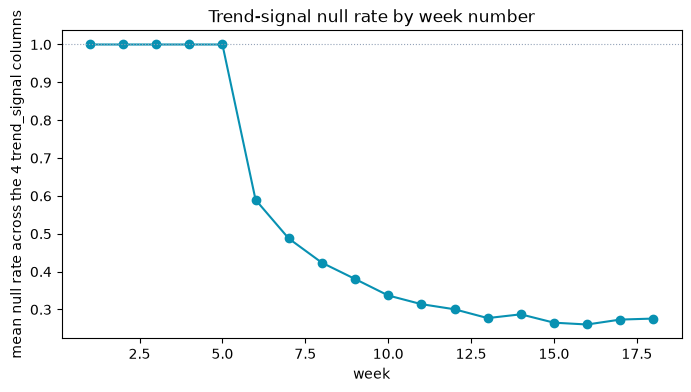

In [10]:
null_by_week = trended.groupby('week')[[f'{f}_trend_signal' for f in TREND_SOURCE_FEATURES]].apply(
    lambda d: d.isna().mean().mean()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(null_by_week.index, null_by_week.values, marker='o', color='#0891b2')
ax.axhline(1.0, color='#94a3b8', linewidth=0.8, linestyle=':')
ax.set_xlabel('week')
ax.set_ylabel('mean null rate across the 4 trend_signal columns')
ax.set_title('Trend-signal null rate by week number')
plt.show()

Expected shape: 100% null through the MIN_GAMES_FOR_TREND-1 games of
each season (the eligibility floor hasn't been reached yet regardless of
week number, since `games_played` resets every season), then a step down
as the season's players clear the floor.

### 5.3 Direction label distribution

In [11]:
for feat in TREND_SOURCE_FEATURES:
    counts = trended[f'{feat}_trend_direction'].value_counts(dropna=False)
    print(f"{feat}:")
    print(counts.to_string())
    print()

target_share:
target_share_trend_direction
<NA>       23326
stable     16833
rising      3371
falling     2163

carry_share:
carry_share_trend_direction
<NA>       30556
stable     11240
rising      2331
falling     1566

offense_pct:
offense_pct_trend_direction
<NA>       21226
stable     15855
rising      4949
falling     3663

rz_opportunity_share:
rz_opportunity_share_trend_direction
<NA>       22811
stable     17864
rising      3032
falling     1986



## 6. Riser/faller lists

`get_usage_trend_leaders` on a real, fully-in-season week (2025 Wk10, well
past the games-played floor for most starters).

In [12]:
SEASON, WEEK = 2025, 10

for feat in TREND_SOURCE_FEATURES:
    for pos in ['RB', 'WR']:
        risers, fallers = get_usage_trend_leaders(trended, SEASON, WEEK, feature=feat, position=pos, top_n=5)
        print(f"=== {feat} risers, {pos}, {SEASON} Wk{WEEK} ===")
        print(risers[['player_display_name', 'team', feat, f'{feat}_ewm3', f'{feat}_trend_signal', f'{feat}_trend_direction']]
              .to_string(index=False))
        print()

=== target_share risers, RB, 2025 Wk10 ===
player_display_name team  target_share  target_share_ewm3  target_share_trend_signal target_share_trend_direction
   Devin Singletary  NYG      0.093750           0.029209                   0.334631                       rising
     Emanuel Wilson   GB      0.030303           0.054519                   0.317138                       rising
       Isaiah Davis  NYJ      0.090909           0.102602                   0.311274                       rising
         Bam Knight  ARI      0.090909           0.058125                   0.287807                       rising
   David Montgomery  DET      0.031250           0.078933                   0.280079                       rising

=== target_share risers, WR, 2025 Wk10 ===
player_display_name team  target_share  target_share_ewm3  target_share_trend_signal target_share_trend_direction
     Rashid Shaheed  SEA      0.083333           0.257251                   0.457019                       rising
 

## What's next

`add_trend_features`/`get_usage_trend_leaders` are wired into
`src/export.py`'s Phase 7 pipeline (`build_trend_snapshot`,
`assemble_player_advanced_stats`'s new `trend` key) — see
`07_export_json.ipynb`. `radar` and `heatmap` (NOTEBOOK_OUTLINE.md Phases
4-5) remain not started; they can slot in as new sibling keys the same way
`trend` just did, no restructuring needed.